In [2]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.utils import io
import random

models_path = os.path.abspath(os.path.join('..', 'models'))
sys.path.append(models_path)

from BKT.bkt_model import ModelBKT

random.seed(42)


In [3]:
with open('../data/preprocessed/assistments_skill_dict.json', 'r') as json_file:
    skill_dict = json.load(json_file)

In [ ]:
results = []
results_with_forget = []

# Redirect tqdm's output to avoid interference
with tqdm(skill_dict.items(), desc="Processing skills") as pbar:
    for skill_id, user_answers in pbar:
        # Suppress output during fit
        with io.capture_output():
            random.shuffle(user_answers)

            # Define the split ratio
            train_size = int(0.8 * len(user_answers))  # 80% for training, 20% for testing

            # Split the shuffled list into train and test
            train_answers = user_answers[:train_size]
            test_answers = user_answers[train_size:]
            try:
                model = ModelBKT(skill_id, train_answers)
                model.fit()
                auc = model.evaluate(test_answers)  # Evaluate model
                results.append({"skill_id": skill_id, "auc": auc})
            except:
                pass
            
            try:
                model = ModelBKT(skill_id, train_answers, allow_forget=True)
                model.fit()
                auc = model.evaluate(test_answers)  # Evaluate model
                results_with_forget.append({"skill_id": skill_id, "auc": auc})
            except:
                pass

Processing skills: 100%|██████████| 113/113 [02:45<00:00,  1.46s/it]


Total number of valid skills: 113


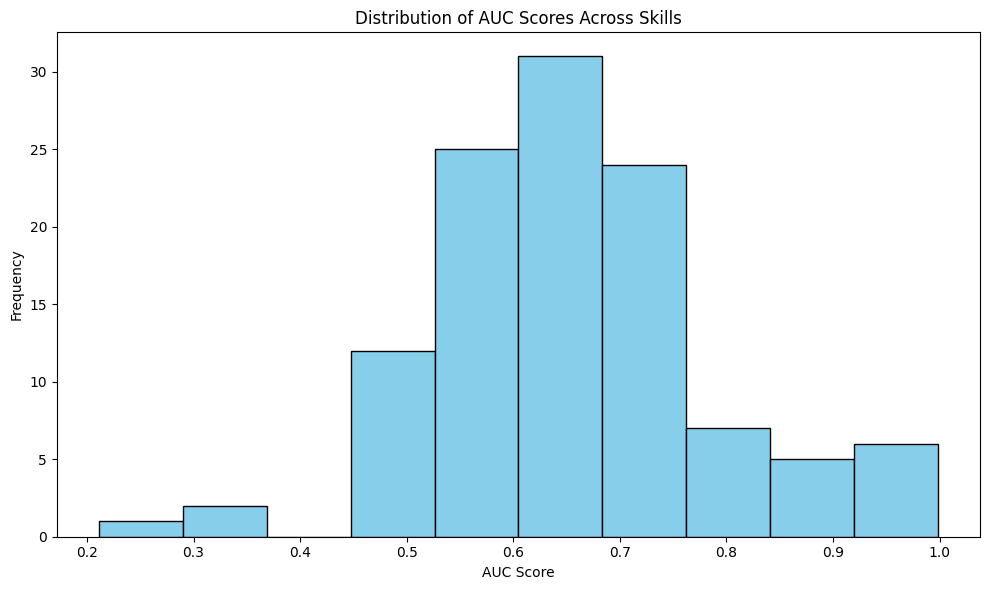

Average AUC across all skills: 0.6572


In [19]:
# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Print the total number of valid skills
print(f"Total number of valid skills: {len(results_df)}")

# Plot a histogram of AUC scores
plt.figure(figsize=(10, 6))
plt.hist(results_df["auc"], bins=10, color="skyblue", edgecolor="black")
plt.xlabel("AUC Score")
plt.ylabel("Frequency")
plt.title("Distribution of AUC Scores Across Skills")
plt.tight_layout()
plt.show()

# Report the average AUC
average_auc = results_df["auc"].mean()
print(f"Average AUC across all skills: {average_auc:.4f}")

![AUC Scores from the Stanford Paper](./../pictures/AUC_results.png)


Our average AUC score (0.657) is above the Marginal 0.62 and managed to achieve the 0.67 mentioned in the paper.

Total number of valid skills: 113


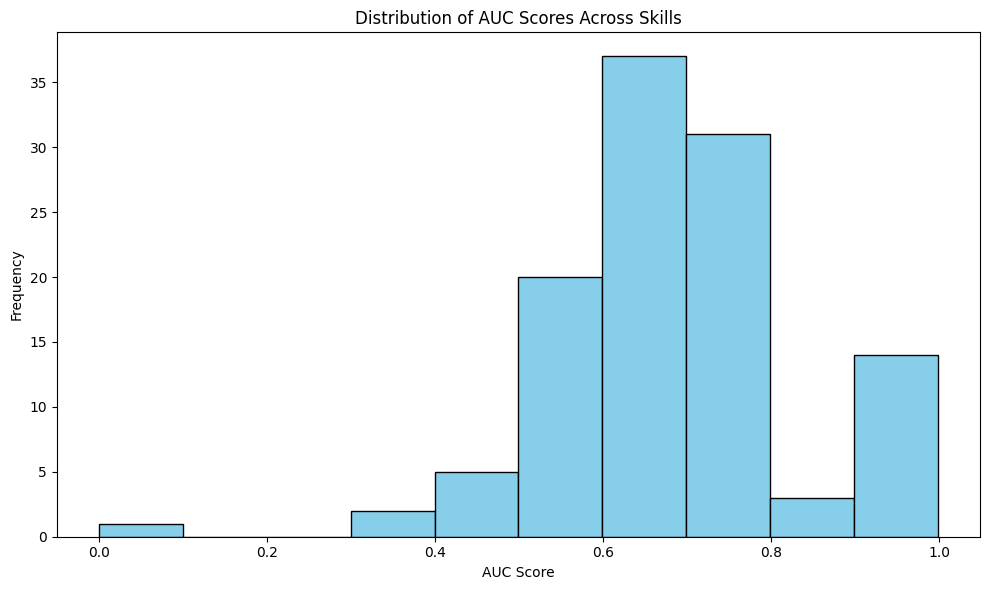

Average AUC across all skills: 0.6814


In [20]:
# Convert results to a DataFrame
results_with_forget_df = pd.DataFrame(results_with_forget)

# Print the total number of valid skills
print(f"Total number of valid skills: {len(results_with_forget_df)}")

# Plot a histogram of AUC scores
plt.figure(figsize=(10, 6))
plt.hist(results_with_forget_df["auc"], bins=10, color="skyblue", edgecolor="black")
plt.xlabel("AUC Score")
plt.ylabel("Frequency")
plt.title("Distribution of AUC Scores Across Skills")
plt.tight_layout()
plt.show()

# Report the average AUC
average_auc = results_with_forget_df["auc"].mean()
print(f"Average AUC across all skills: {average_auc:.4f}")


AUC further improved to 0.681 if allowing to forget.